In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

loan_data = pd.read_csv('../datasets/decision/train_loan_80.csv')

display(loan_data.head())

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,0,Graduate,No,6000,2250.0,265.0,360.0,1.0,Semiurban,N
1,Male,Yes,0,Graduate,No,2958,2900.0,131.0,360.0,1.0,Semiurban,Y
2,Male,Yes,2,Graduate,No,6250,1695.0,210.0,360.0,1.0,Semiurban,Y
3,Male,Yes,0,Graduate,No,2083,3150.0,128.0,360.0,1.0,Semiurban,Y
4,Male,No,0,Graduate,No,4166,0.0,98.0,360.0,0.0,Semiurban,N


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,6000,2250.0,265.0,360.0,1.0,True,True,False,False,False,False,False,True,False,False
1,2958,2900.0,131.0,360.0,1.0,True,True,False,False,False,False,False,True,False,True
2,6250,1695.0,210.0,360.0,1.0,True,True,False,True,False,False,False,True,False,True
3,2083,3150.0,128.0,360.0,1.0,True,True,False,False,False,False,False,True,False,True
4,4166,0.0,98.0,360.0,0.0,True,False,False,False,False,False,False,True,False,False


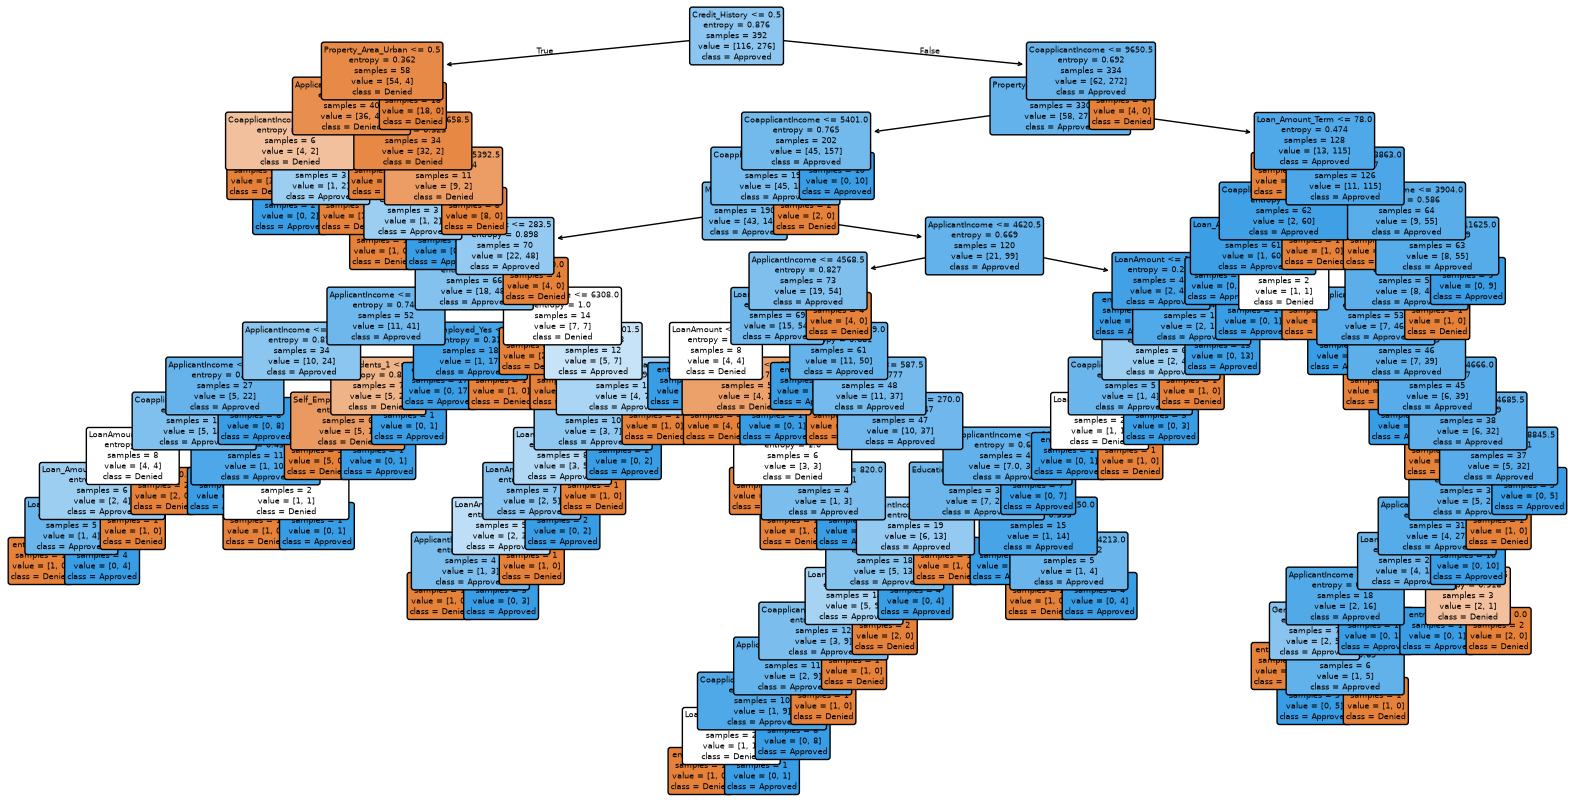

In [10]:
# 범주형 데이터를 숫자로 변환(원-핫 인코딩)
# drop_first=True : 첫 번째 범주는 제거하여 다중공선성 방지

loan_encoded = pd.get_dummies(loan_data, drop_first=True)

# 인코딩된 데이터 확인
display(loan_encoded.head())

# 입력 데이터(X) : Loan_Status_Y를 제외한 모든 변수
x = loan_encoded.drop(columns=['Loan_Status_Y'])

# 목표 데이터(y) : 대출 승인 여부(예측 대상)
y = loan_encoded['Loan_Status_Y']

# 훈련용(80%)과 테스트용(20%) 데이터 분리
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,      # 테스트 데이터 비율 20%
    random_state=42     # 항상 같은 결과가 나오도록 난수 고정
)

# 의사결정나무 모델 생성
model = DecisionTreeClassifier(
    criterion='entropy',    # 분할 기준 : 엔트로피(정보이득)
    random_state=42         # 난수 고정
)

# 모델 학습
model.fit(x_train, y_train)

# 테스트 데이터로 예측
pred = model.predict(x_test)

# 의사결정나무 시각화
plt.figure(figsize=(20, 10))   # 그래프 크기 설정

plot_tree(
    model,                          # 학습된 의사결정나무 모델
    feature_names=x.columns,        # 입력 변수 이름 표시
    class_names=['Denied', 'Approved'],  # 클래스 이름 표시
    filled=True,                    # 클래스별 색상 채우기
    rounded=True,                   # 노드를 둥근 모서리로 표시
    fontsize=6                      # 글자 크기
)

# 그래프 출력
plt.show()

In [11]:
# 저장
import joblib
joblib.dump(model, 'loan_model.pkl')
joblib.dump(x.columns, 'model_features.pkl')
report = classification_report(y_test, pred, target_names=['Denied', 'Approved'])
print(report)

              precision    recall  f1-score   support

      Denied       0.57      0.39      0.46        33
    Approved       0.74      0.85      0.79        66

    accuracy                           0.70        99
   macro avg       0.65      0.62      0.63        99
weighted avg       0.68      0.70      0.68        99

